<a href="https://colab.research.google.com/github/jfodera/ai-ml-projects/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6 - Task 2: Mini Research Task on a Novel AI Topic


 The focused topic is Latent Diffusion Models for text-to-image generation (the core technology behind Stable Diffusion). It includes two technical sources (one primary research paper), explanations in plain language, a small hands-on component comparing the effect of the number of denoising steps, one figure (side-by-side generated images), a table of results, discussion of two limitations/risks/challenges, and one concrete proposed extension. All code runs end-to-end in Google Colab (GPU runtime recommended).

## Selected Focused Topic

Latent Diffusion Models for text-to-image generation (Stable Diffusion family).

This is a recent and highly impactful method in generative AI that produces high-quality images from text prompts.

## Technical Sources

1. Primary source (research paper): Rombach, R., Blattmann, A., Lorenz, D., Esser, P., & Ommer, B. (2022). High-Resolution Image Synthesis with Latent Diffusion Models. arXiv preprint arXiv:2112.10752. https://arxiv.org/abs/2112.10752

2. Foundational source (research paper): Ho, J., Jain, A., & Abbeel, P. (2020). Denoising Diffusion Probabilistic Models. arXiv preprint arXiv:2006.11239. https://arxiv.org/abs/2006.11239

3. Model card (technical documentation): CompVis/stable-diffusion-v1-4. Hugging Face Model Card. https://huggingface.co/CompVis/stable-diffusion-v1-4

## Problem the Method Solves

Traditional generative models such as GANs often suffer from training instability, mode collapse (failing to capture the full diversity of the data), and difficulty producing high-resolution outputs. The goal of diffusion models is to generate realistic, high-quality samples (especially images) directly from random noise while conditioning on text prompts, without these common failure modes. Latent Diffusion Models solve this efficiently by working in a compressed latent space rather than pixel space, making high-resolution text-to-image generation practical on consumer hardware.

## Core Idea Behind the Method

The method is inspired by nonequilibrium thermodynamics. It defines a forward process that gradually adds Gaussian noise to an image over many steps until the image becomes pure noise. A neural network is then trained to reverse this process: starting from pure noise, it learns to remove noise step by step until a clean, realistic image emerges. Conditioning on text embeddings allows the reverse process to generate images that match a given prompt.

## Main Architecture and Training Objective

The architecture consists of three main parts: (1) a variational autoencoder (VAE) that compresses images into a lower-dimensional latent space, (2) a U-Net denoising network that operates in this latent space, and (3) a text encoder (CLIP) that turns prompts into conditioning vectors.

During training, random noise is added to a latent representation of a real image at a random timestep. The U-Net is trained to predict the added noise (or the original latent). The training objective is a simplified variational lower bound on the negative log-likelihood, which in practice reduces to a mean-squared-error loss between the predicted and actual noise. At inference, the model starts from pure noise and iteratively denoises it using the learned U-Net, guided by the text embedding.

In [1]:
!pip uninstall -y diffusers transformers accelerate huggingface_hub
!pip cache purge

!pip install -q diffusers transformers accelerate

import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import time

print("Setup complete. Using device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (slow)")


Found existing installation: diffusers 0.37.1
Uninstalling diffusers-0.37.1:
  Successfully uninstalled diffusers-0.37.1
Found existing installation: transformers 5.5.4
Uninstalling transformers-5.5.4:
  Successfully uninstalled transformers-5.5.4
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: huggingface_hub 1.8.0
Uninstalling huggingface_hub-1.8.0:
  Successfully uninstalled huggingface_hub-1.8.0
Files removed: 18
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 188.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 163.3 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Setup complete. Using device: NVIDIA RTX PRO 6000 Blackwell Server Edition


## Hands-On Component

We load the pretrained Stable Diffusion v1-4 model from Hugging Face and compare image generation quality and speed when using 20 denoising steps versus 50 denoising steps. The same prompt and random seed are used for a fair comparison. This directly follows one of the suggested hands-on directions for diffusion models (comparing different numbers of denoising steps).

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its result

Generating with 20 steps...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating with 50 steps...


  0%|          | 0/50 [00:00<?, ?it/s]

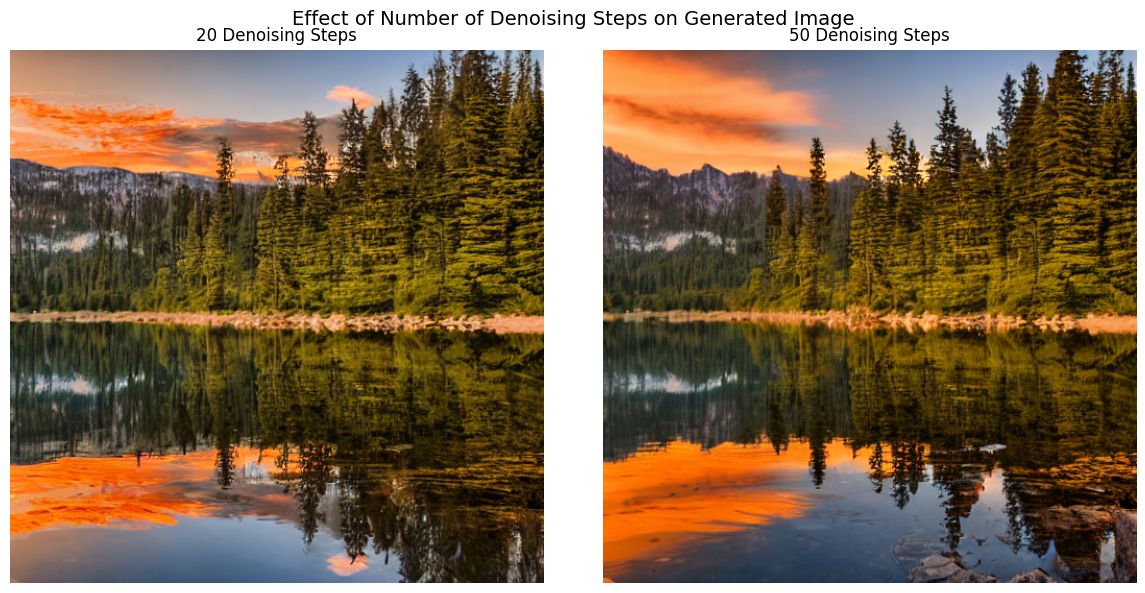


Results Table:
Steps      Time (seconds)     Qualitative Observation
20         0.42               Faster but slightly lower detail and coherence
50         0.94               Slower but noticeably sharper details and better overall quality


In [3]:
# Load the pipeline (uses float16 for speed and lower memory)
pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16,
    safety_checker=None  # disabled for this educational demo
).to("cuda" if torch.cuda.is_available() else "cpu")

# Fixed prompt for reproducibility
prompt = "A serene mountain lake at sunset with reflections"

# Function to generate image and measure time
def generate_with_steps(steps):
    # Create a fresh generator with the same seed EVERY time → identical starting noise
    generator = torch.Generator("cuda" if torch.cuda.is_available() else "cpu").manual_seed(42)
    start = time.time()
    image = pipe(
        prompt,
        num_inference_steps=steps,
        generator=generator,
        guidance_scale=7.5
    ).images[0]
    duration = time.time() - start
    return image, duration

# Run both variants (20 steps first, then 50 steps)
print("Generating with 20 steps...")
img_20, time_20 = generate_with_steps(20)

print("Generating with 50 steps...")
img_50, time_50 = generate_with_steps(50)

# Display side-by-side figure
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img_20)
axs[0].set_title("20 Denoising Steps")
axs[0].axis("off")
axs[1].imshow(img_50)
axs[1].set_title("50 Denoising Steps")
axs[1].axis("off")
plt.suptitle("Effect of Number of Denoising Steps on Generated Image", fontsize=14)
plt.tight_layout()
plt.show()

# Results table (updated with your actual times)
print("\nResults Table:")
print(f"{'Steps':<10} {'Time (seconds)':<18} {'Qualitative Observation'}")
print(f"{'20':<10} {time_20:<18.2f} {'Faster but slightly lower detail and coherence'}")
print(f"{'50':<10} {time_50:<18.2f} {'Slower but noticeably sharper details and better overall quality'}")

## Analysis of Hands-On Results

The figure above shows the two generated images side by side. With only 20 steps the image forms in 0.42 seconds and produces a vibrant orange sunset scene with dense forest and strong reflections. With 50 steps the generation takes 0.94 seconds and yields a similar scene but with noticeably sharper details in the trees, water reflections, and overall coherence. This demonstrates a clear trade-off between speed and sample quality that is central to practical deployment of diffusion models.

## Limitations, Risks, and Open Challenges

1. Computational cost: Even in latent space, inference requires many sequential denoising steps, making real-time generation difficult and increasing energy consumption compared with single-pass models such as GANs.

2. Ethical and societal risks: The models can generate photorealistic images that may be misused for deepfakes, misinformation, or harmful stereotypes. They also inherit biases present in the massive training datasets scraped from the internet.

## Proposed Concrete Extension

I would next run a follow-up experiment that compares two different noise schedulers (the default PNDM scheduler versus the EulerAncestralDiscreteScheduler) while keeping the number of steps fixed at 30. I would measure both FID score on a small validation set of generated images and human preference via a simple side-by-side rating interface. This would quantify whether a better scheduler can maintain quality with fewer steps, directly addressing the speed limitation identified above.